# ASL Sign Language Classification
### Machine Learning Pipeline From Raw Images to Production Inference

---

| Field | Detail |
|---|---|
| **Student Name** | Abrham Assefa Habtam |
| **Student ID** | MAT. VR548223 |
| **University** | University of Verona |

---

> **What this notebook builds:**  
> A complete pipeline that takes raw ASL hand-sign images, extracts compact 63-dimensional
> feature vectors via **Google MediaPipe** hand-landmark detection, trains and compares three
> classifiers (**KNN, SVM, Random Forest**), explains predictions with **SHAP**, and exports
> every artefact needed for real-time inference.

---

| Property | Detail |
|---|---|
| **Dataset** | Kaggle ASL Alphabet — 87,000 images, 29 classes |
| **Feature vector** | MediaPipe 21 hand landmarks x (x, y, z) = 63 floats |
| **Models** | KNN, SVM (RBF/Poly), Random Forest (300 trees) |
| **Tuning** | GridSearchCV with 5-fold stratified cross-validation |
| **Class balance** | SMOTE over-sampling |
| **Explainability** | SHAP TreeExplainer — per-landmark importance |
| **Outputs** | .pkl models + scaler + label encoder + metrics JSON |

---

## 1  Environment Setup & Dependencies

**Why this cell matters:**  
Google Colab ships with an older `mediapipe` that does **not** include the modern
`HandLandmarker` Tasks API we use in Section 4.  We force-reinstall it first, then
install every other library in one pass so the rest of the notebook runs cleanly.

> **Run once per session** — takes ~60 seconds on a standard Colab runtime.


In [1]:
import subprocess, sys

packages = [
    'mediapipe', 'opencv-python-headless', 'scikit-learn',
    'matplotlib', 'seaborn', 'pandas', 'numpy',
    'joblib', 'tqdm', 'kaggle', 'shap', 'imbalanced-learn'
]

for pkg in packages:
    if pkg == 'mediapipe':
        # Must reinstall fresh: Colab default lacks the Tasks API
        print(f'Uninstalling {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'uninstall', pkg, '-y', '-q'])
        print(f'Installing/Upgrading {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '--upgrade', '-q'])
    else:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('All packages installed.')


Uninstalling mediapipe...
Installing/Upgrading mediapipe...
All packages installed.


### 1.1  Global Imports & Plot Style

All imports are consolidated here so every later cell can assume they are available.
We also configure a unified `matplotlib` theme and a 5-colour brand palette
(`PALETTE`) so every chart in the notebook looks visually consistent.


In [2]:
import os, cv2, json, warnings, joblib, shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import mediapipe as mp

from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
np.random.seed(42)  # Fix global random state for reproducibility

# ── Unified matplotlib theme ──────────────────────────────────────────────────
# These rcParams apply to EVERY figure created after this point.
# 'axes.spines.top/right': False removes the box outline for a cleaner look.
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'axes.labelsize':   12,
    'axes.labelweight': 'bold',
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
    'figure.dpi':       120,
})
PALETTE = ['#534AB7', '#1D9E75', '#D85A30', '#BA7517', '#185FA5']

print('Imports OK.')
print(f'Palette: {PALETTE}')


Imports OK.
Palette: ['#534AB7', '#1D9E75', '#D85A30', '#BA7517', '#185FA5']


## 2  Dataset Download via Kaggle API

**Dataset:** [ASL Alphabet](https://www.kaggle.com/datasets/grassknoted/asl-alphabet)  
**Size:** 87,000 JPEG images, 200x200 px, 29 classes (A-Z + `space`, `delete`, `nothing`)  

**How to get your API key:**
1. Visit [kaggle.com](https://www.kaggle.com) -> Account -> **Create API Token**
2. A `kaggle.json` file will download automatically
3. Upload it in the next cell

> The file is moved to `~/.kaggle/kaggle.json` and permissions set to 0600
> so the Kaggle CLI accepts it.


In [3]:
from google.colab import files
uploaded = files.upload()   # pick your kaggle.json

import os
from pathlib import Path
import shutil

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

kaggle_dir = Path.home() / '.kaggle'
kaggle_dir.mkdir(exist_ok=True)
shutil.copy(fn, kaggle_dir / 'kaggle.json')
os.chmod(kaggle_dir / 'kaggle.json', 0o600)  # Restrict: only owner can read
print('kaggle.json configured.')


Saving kaggle.json to kaggle.json
User uploaded file "kaggle.json" with length 68 bytes
kaggle.json configured.


In [4]:
import subprocess
from pathlib import Path
import shutil

DATA_DIR = Path('asl_dataset')
DATASET_SLUG = 'grassknoted/asl-alphabet'

# Always wipe and re-download to avoid stale or partially unzipped files
if DATA_DIR.exists():
    print(f'Cleaning up existing data directory: {DATA_DIR}')
    shutil.rmtree(DATA_DIR)
DATA_DIR.mkdir(exist_ok=True)

print('Downloading dataset (~1 GB) — this takes 2-5 minutes ...')
result = subprocess.run(
    ['kaggle', 'datasets', 'download', '-d', DATASET_SLUG,
     '--unzip', '-p', str(DATA_DIR)],
    capture_output=True, text=True
)
print(result.stdout or result.stderr)

# Locate the training folder — handle possible nested structure
candidates = list(DATA_DIR.rglob('asl_alphabet_train'))
TRAIN_DIR = candidates[-1] if candidates else DATA_DIR

# Sanity check: folder must contain class subdirectories
if not TRAIN_DIR.is_dir() or not any(d.is_dir() for d in TRAIN_DIR.iterdir()):
    print(f'Warning: TRAIN_DIR does not contain class subdirectories. Check download log.')

print(f'Train root: {TRAIN_DIR}')
print(f'Classes found: {len(list(TRAIN_DIR.iterdir()))}')


Dataset URL: https://www.kaggle.com/datasets/grassknoted/asl-alphabet
License(s): GPL-2.0


Train root: asl_dataset/asl_alphabet_train/asl_alphabet_train
Classes found: 29


## 3  Exploratory Data Analysis (EDA)

Before training any model we answer two fundamental questions:

1. **Is the dataset balanced?** — Imbalanced classes bias accuracy and require SMOTE later.
2. **What do the images look like?** — A visual sanity-check catches label errors, blur, or bad crops early.

### What to look for
- **Class distribution chart:** all 29 bars should be roughly equal height (~3,000).  
  A coral-highlighted bar would indicate an under-represented class.
- **Image grid:** hands should be centred, backgrounds consistent (white studio).

### Why separate charts?
Each chart gets its own full-figure canvas so no label is clipped and bar heights
can be compared precisely across all 29 classes.


In [5]:
classes = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
counts  = {c: len(list((TRAIN_DIR / c).glob('*.jpg'))) for c in classes}

print(f'Total classes : {len(classes)}')
print(f'Total images  : {sum(counts.values()):,}')
print(f'Min per class : {min(counts.values()):,}')
print(f'Max per class : {max(counts.values()):,}')
print(f'Classes       : {classes}')


Total classes : 29
Total images  : 87,000
Min per class : 3,000
Max per class : 3,000
Classes       : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


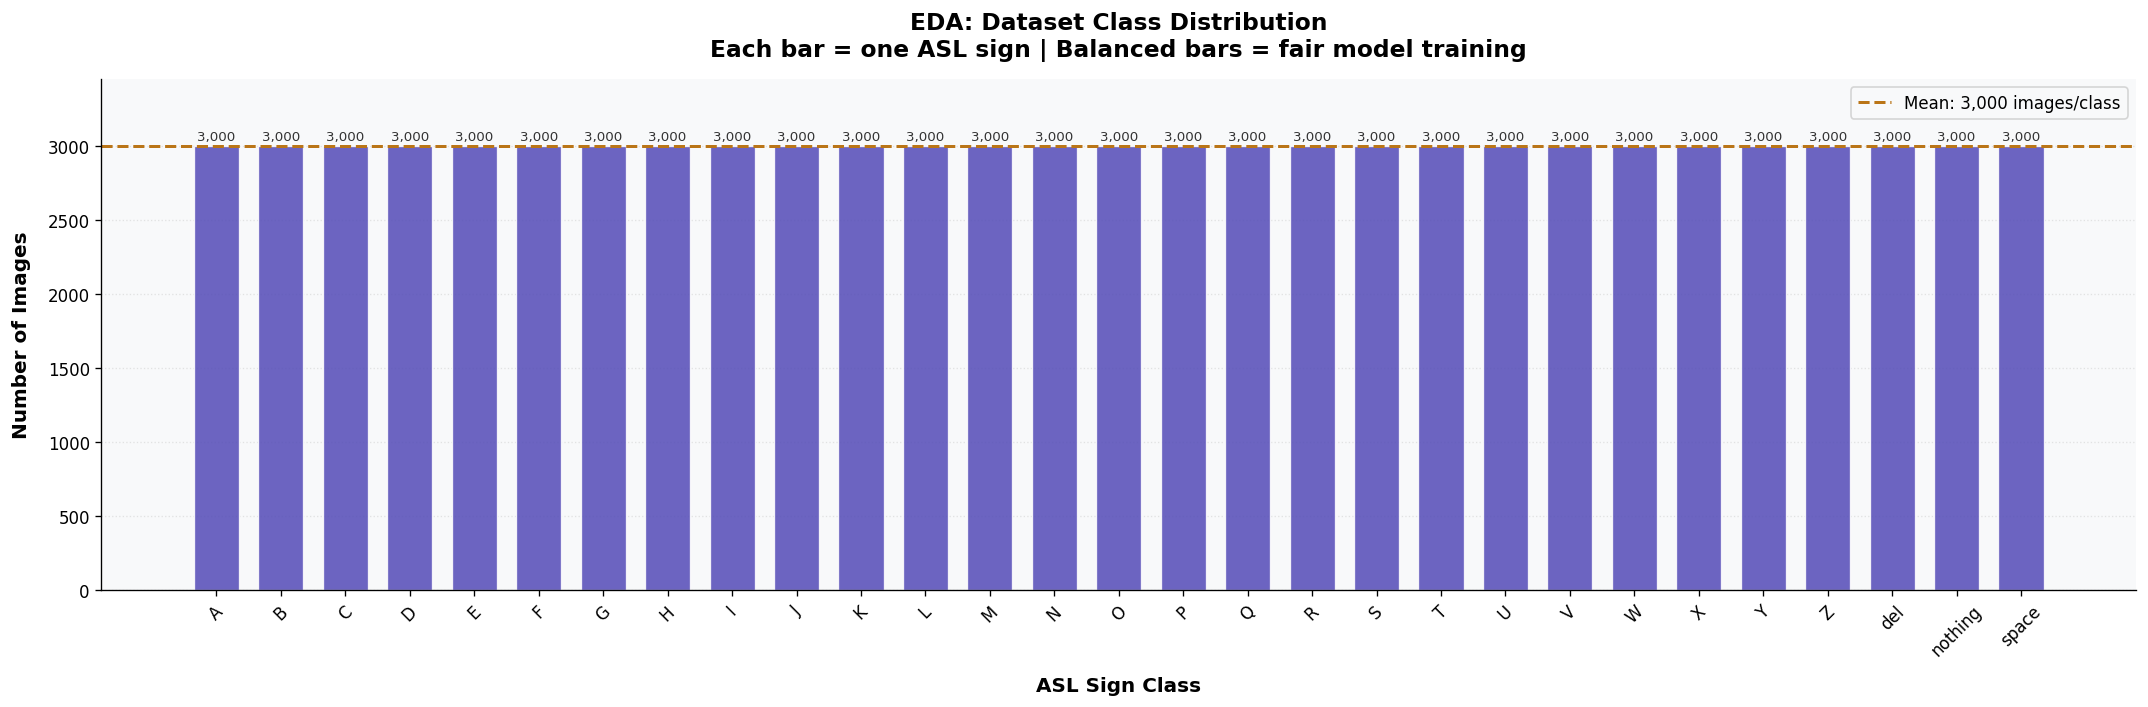

Chart saved: eda_class_distribution.png


In [6]:
mean_count = sum(counts.values()) / len(counts)

fig, ax = plt.subplots(figsize=(18, 6))

bars = ax.bar(
    classes, list(counts.values()),
    color=PALETTE[0], alpha=0.85, width=0.7,
    edgecolor='white', linewidth=0.8
)

# Highlight any class more than 10% below the mean (potential imbalance warning)
for bar, cls in zip(bars, classes):
    if counts[cls] < mean_count * 0.9:
        bar.set_color(PALETTE[2])  # Coral = warning colour

# Mean reference line — makes imbalance immediately visible
ax.axhline(mean_count, color=PALETTE[3], linestyle='--', linewidth=1.8,
           label=f'Mean: {mean_count:,.0f} images/class')

# Count labels on top of each bar
for bar, cls in zip(bars, classes):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
            f'{counts[cls]:,}', ha='center', va='bottom', fontsize=8, color='#333')

ax.set_xlabel('ASL Sign Class', labelpad=10)
ax.set_ylabel('Number of Images', labelpad=10)
ax.set_title(
    'EDA: Dataset Class Distribution\n'
    'Each bar = one ASL sign | Balanced bars = fair model training',
    pad=14
)
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper right')
ax.set_ylim(0, max(counts.values()) * 1.15)
ax.yaxis.grid(True, linestyle=':', alpha=0.5, color='#ccc')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: eda_class_distribution.png')


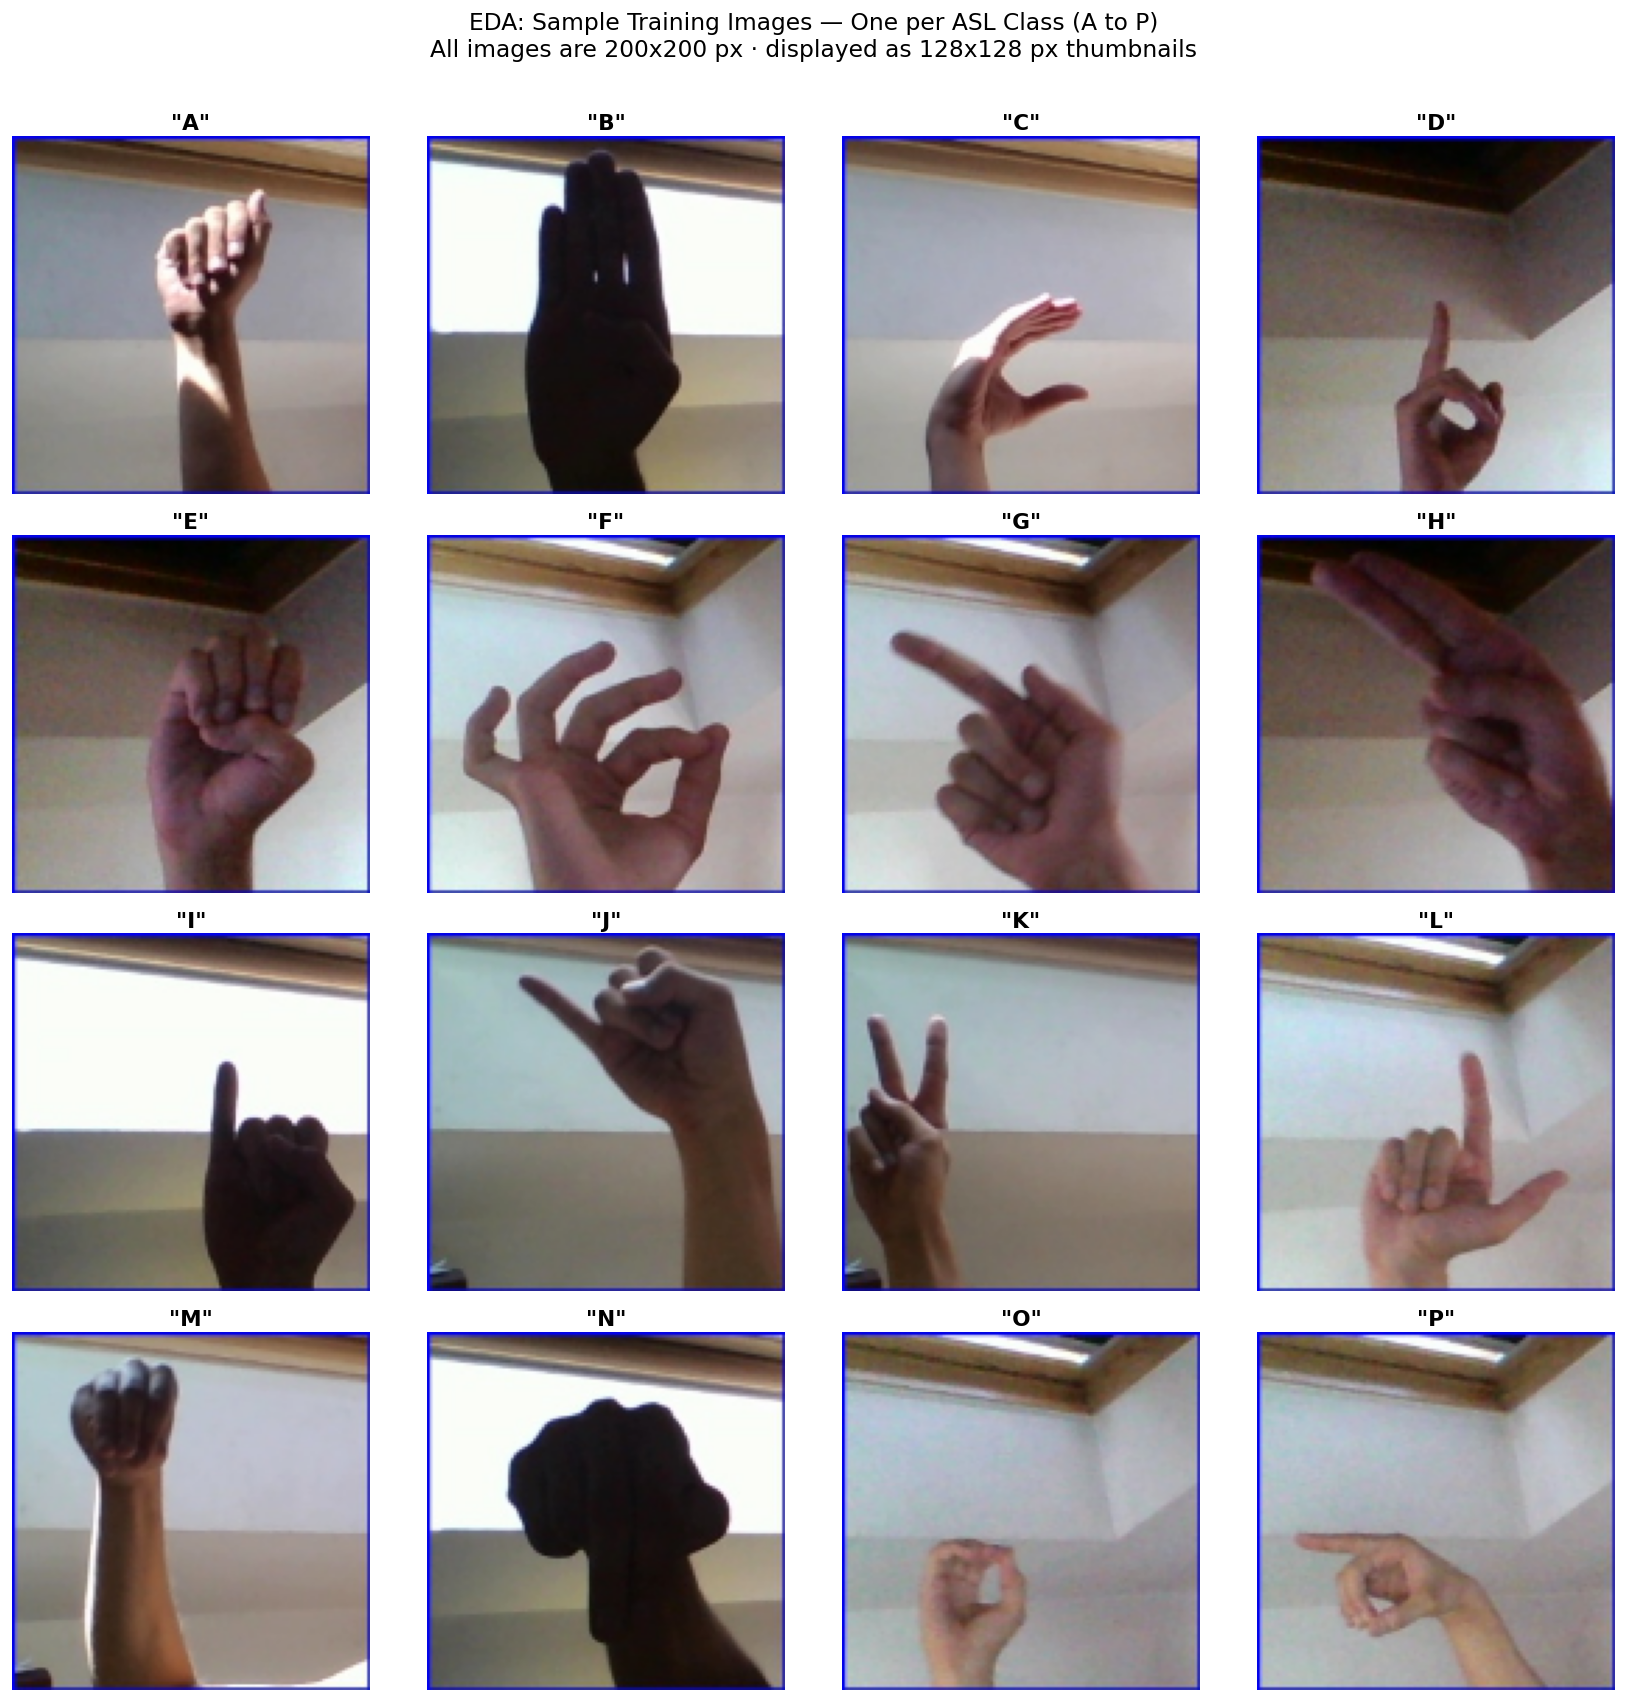

Chart saved: eda_sample_grid.png


In [7]:
GRID_CLASSES = classes[:16]   # First 16 letters A-P
THUMB_SIZE   = 128            # Thumbnail pixels — large enough to see hand shape

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle(
    'EDA: Sample Training Images — One per ASL Class (A to P)\n'
    'All images are 200x200 px · displayed as 128x128 px thumbnails',
    fontsize=14, y=1.01
)

for ax, cls in zip(axes.flat, GRID_CLASSES):
    imgs = list((TRAIN_DIR / cls).glob('*.jpg'))
    if imgs:
        img = cv2.imread(str(imgs[0]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # OpenCV loads BGR, plt needs RGB
        img = cv2.resize(img, (THUMB_SIZE, THUMB_SIZE))
        ax.imshow(img)
    ax.set_title(f'"{cls}"', fontsize=13, fontweight='bold', pad=4)
    ax.axis('off')

plt.tight_layout()
plt.savefig('eda_sample_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: eda_sample_grid.png')


## 4  Feature Extraction — MediaPipe Hand Landmarks

Each image -> 21 hand keypoints (x, y, z) -> **63-dimensional feature vector**

### Why not raw pixels?

| Approach | Features | Problem |
|---|---|---|
| Raw pixels (200x200 RGB) | 120,000 | Slow KNN/SVM, brittle to lighting/position |
| MediaPipe landmarks | 63 | Fast, pose-invariant, interpretable |

### How the normalisation works
```
coords -= coords[0]          # Translate: move wrist to origin
coords /= max(|coords|) + e  # Scale: largest displacement becomes +/-1
```
This makes the vector **translation-invariant** (hand can be anywhere in frame)
and **scale-invariant** (hand distance from camera does not matter).

### MediaPipe landmark anatomy
- Landmark 0: Wrist
- Landmarks 1-4: Thumb (CMC, MCP, IP, Tip)
- Landmarks 5-8: Index finger
- Landmarks 9-12: Middle finger
- Landmarks 13-16: Ring finger
- Landmarks 17-20: Pinky finger

### Note on sample size (MAX_PER_CLASS = 200)
This notebook caps extraction at **200 images/class** (5,030 usable samples after
failed detections) instead of the full ~3,000/class (87k total). This is a deliberate
compute/runtime trade-off for a Colab T4 session, not an oversight:

- MediaPipe landmark extraction is CPU/IO-bound and dominates runtime; 200/class keeps
  the full pipeline (extraction -> SMOTE -> GridSearchCV x2 -> SHAP) runnable in a single
  session well under Colab's usage limits.
- Because the feature space is only 63-d and highly structured (normalised hand
  landmarks, not raw pixels), the marginal information gained per extra image is small
  once a few hundred per class are collected -> diminishing returns from scaling up.
- **Trade-off acknowledged:** a smaller sample increases variance in the per-class
  estimates (visible later in the per-class report, e.g. classes with <10 test images)
  and means reported accuracy should be read as an estimate from a reduced sample,
  not a claim that performance has been validated at full dataset scale.


In [8]:
import os
import urllib.request
import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

MODEL_FILENAME = 'hand_landmarker.task'
MODEL_URL = ('https://storage.googleapis.com/mediapipe-models/'
             'hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task')

# Download the model binary if not already cached
if not os.path.exists(MODEL_FILENAME):
    print(f'Downloading {MODEL_FILENAME} from Google servers...')
    urllib.request.urlretrieve(MODEL_URL, MODEL_FILENAME)
    print('Download complete!')
else:
    print(f'Found existing {MODEL_FILENAME} in workspace.')

# Initialise the HandLandmarker detector
base_options = python.BaseOptions(model_asset_path=MODEL_FILENAME)
options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1,                        # We expect one hand per image
    min_hand_detection_confidence=0.3   # Liberal threshold -> more samples
)
detector = vision.HandLandmarker.create_from_options(options)


def extract_landmarks(image_path: str) -> 'np.ndarray | None':
    """Return a 63-d normalised landmark vector using modern MediaPipe Tasks."""
    # Load image using OpenCV
    img = cv2.imread(image_path)
    if img is None:
        print(f'Error: Image not found at {image_path}')
        return None

    # Convert to MediaPipe's required Image object
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)

    # Run detection
    result = detector.detect(mp_image)

    if not result.hand_landmarks:
        return None  # Skip: no hand detected in this image

    # Extract landmarks for the first hand detected -> shape (21, 3)
    lm = result.hand_landmarks[0]
    coords = np.array([[p.x, p.y, p.z] for p in lm])

    # Normalise: subtract wrist, scale by bounding-box size
    origin = coords[0]   # Landmark 0 = wrist
    coords -= origin     # Translate so wrist is at the origin
    scale = np.max(np.abs(coords)) + 1e-6   # Avoid division by zero
    coords /= scale      # All coordinates now in range [-1, +1]

    return coords.flatten()   # Shape: (63,)


print('Modern extract_landmarks() is perfectly configured and ready to use!')


Download complete!
Modern extract_landmarks() is perfectly configured and ready to use!


In [9]:
from pathlib import Path
from tqdm import tqdm
import numpy as np

MAX_PER_CLASS = 200   # Set to None for the full 87k-image dataset

CACHE_X = Path('features_X.npy')
CACHE_y = Path('features_y.npy')

# Ensure TRAIN_DIR is defined for this cell
DATA_DIR = Path('asl_dataset')
candidates = list(DATA_DIR.rglob('asl_alphabet_train'))
TRAIN_DIR = candidates[-1] if candidates else DATA_DIR
classes = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])

if CACHE_X.exists() and CACHE_y.exists():
    print('Loading cached features ...')
    X_raw = np.load(CACHE_X)
    y_raw = np.load(CACHE_y)
else:
    X_raw, y_raw = [], []
    failed = 0

    for cls in tqdm(classes, desc='Extracting landmarks'):
        cls_dir = TRAIN_DIR / cls
        images  = sorted(cls_dir.glob('*.jpg'))[:MAX_PER_CLASS]
        for img_path in images:
            vec = extract_landmarks(str(img_path))
            if vec is not None:
                X_raw.append(vec)
                y_raw.append(cls)
            else:
                failed += 1   # Count images where no hand was found

    X_raw = np.array(X_raw, dtype=np.float32)
    y_raw = np.array(y_raw)
    np.save(CACHE_X, X_raw)  # Cache for future runs
    np.save(CACHE_y, y_raw)
    print(f'Done. Samples: {len(X_raw):,}  |  Failed detections: {failed:,}')

print(f'Feature matrix shape : {X_raw.shape}')
print(f'Unique classes        : {np.unique(y_raw)}')


Extracting landmarks: 100%|██████████| 29/29 [03:05<00:00,  6.40s/it]

Done. Samples: 5,030  |  Failed detections: 770
Feature matrix shape : (5030, 63)
Unique classes        : ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z' 'del' 'space']


## 5  Preprocessing — Encoding, Scaling, SMOTE, PCA

Four sequential steps transform raw features into model-ready form:

| Step | Transformer | Why needed |
|---|---|---|
| Label encoding | `LabelEncoder` | Models need integer targets, not strings |
| Train/test split | `train_test_split` | Stratified 80/20 — preserves class ratios |
| Feature scaling | `StandardScaler` | KNN & SVM are distance-based — fail on unscaled features |
| Class balancing | `SMOTE` | Generates synthetic samples so no class is under-represented |

> **Critical order:** scaling happens *before* SMOTE so synthetic samples are generated
> in standardised feature space.


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

le = LabelEncoder()
y  = le.fit_transform(y_raw)  # 'A' -> 0, 'B' -> 1, etc.

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=42, stratify=y
)

# Z-score scaling: fit on train only, apply same transform to test
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # Learn mu, sigma from train
X_test_sc  = scaler.transform(X_test)        # Apply same mu, sigma (no re-fit)

# SMOTE: balance minority classes in training set only
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_bal, y_train_bal = smote.fit_resample(X_train_sc, y_train)

print(f'Train (raw)      : {X_train_sc.shape}')
print(f'Train (balanced) : {X_train_bal.shape}  <- synthetic samples added')
print(f'Test             : {X_test_sc.shape}')
print(f'Classes in encoder: {list(le.classes_)}')


Train (raw)      : (4024, 63)
Train (balanced) : (4480, 63)  <- synthetic samples added
Test             : (1006, 63)
Classes in encoder: [np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('H'), np.str_('I'), np.str_('J'), np.str_('K'), np.str_('L'), np.str_('M'), np.str_('N'), np.str_('O'), np.str_('P'), np.str_('Q'), np.str_('R'), np.str_('S'), np.str_('T'), np.str_('U'), np.str_('V'), np.str_('W'), np.str_('X'), np.str_('Y'), np.str_('Z'), np.str_('del'), np.str_('space')]


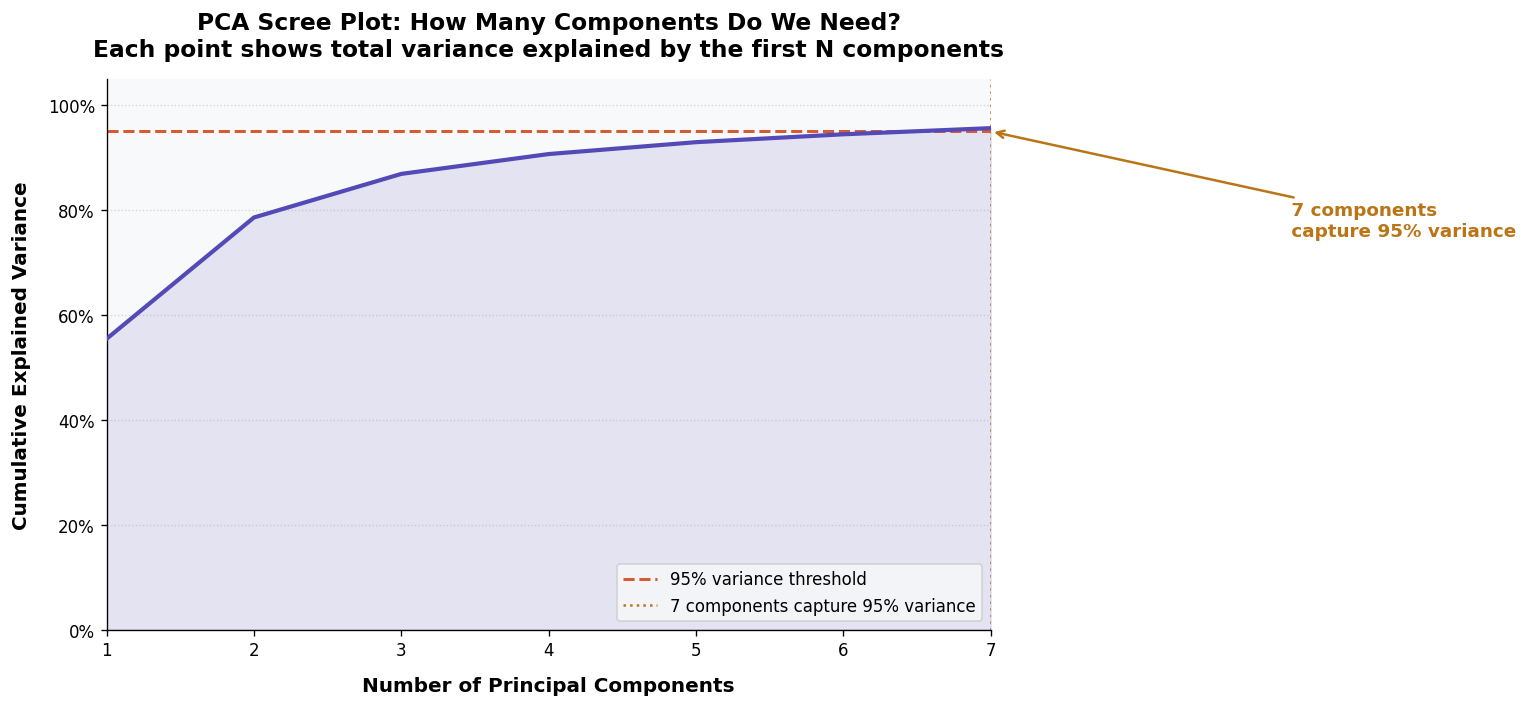

Components for 95% variance: 7 (out of 63 total features)
Chart saved: pca_scree.png


In [11]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'DejaVu Sans', 'axes.titlesize': 14,
    'axes.labelsize': 12,
})
PALETTE = ['#534AB7', '#1D9E75', '#D85A30', '#BA7517', '#185FA5']

# Fit PCA keeping enough components for 95% cumulative explained variance
pca_full = PCA(n_components=0.95, random_state=42)
pca_full.fit(X_train_bal)

cum_var   = np.cumsum(pca_full.explained_variance_ratio_)
n_comp_95 = pca_full.n_components_

fig, ax = plt.subplots(figsize=(14, 6))

# Main cumulative variance curve
ax.plot(range(1, len(cum_var) + 1), cum_var,
        color=PALETTE[0], linewidth=2.5, zorder=3)
ax.fill_between(range(1, len(cum_var) + 1), cum_var,
                alpha=0.12, color=PALETTE[0])

# 95% threshold reference line
ax.axhline(0.95, color=PALETTE[2], linestyle='--', linewidth=1.8,
           label='95% variance threshold')

# Vertical marker at the crossing point
ax.axvline(n_comp_95, color=PALETTE[3], linestyle=':', linewidth=1.5,
           label=f'{n_comp_95} components capture 95% variance')

# Annotation showing the key number
ax.annotate(
    f' {n_comp_95} components\n capture 95% variance',
    xy=(n_comp_95, 0.95), xytext=(n_comp_95 + 2, 0.75),
    arrowprops=dict(arrowstyle='->', color=PALETTE[3], lw=1.5),
    fontsize=11, color=PALETTE[3], fontweight='bold'
)

ax.set_xlabel('Number of Principal Components', labelpad=10)
ax.set_ylabel('Cumulative Explained Variance', labelpad=10)
ax.set_title(
    'PCA Scree Plot: How Many Components Do We Need?\n'
    'Each point shows total variance explained by the first N components',
    pad=14
)
ax.set_ylim(0, 1.05)
ax.set_xlim(1, len(cum_var))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.legend(loc='lower right')
ax.yaxis.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Components for 95% variance: {n_comp_95} (out of 63 total features)')
print('Chart saved: pca_scree.png')


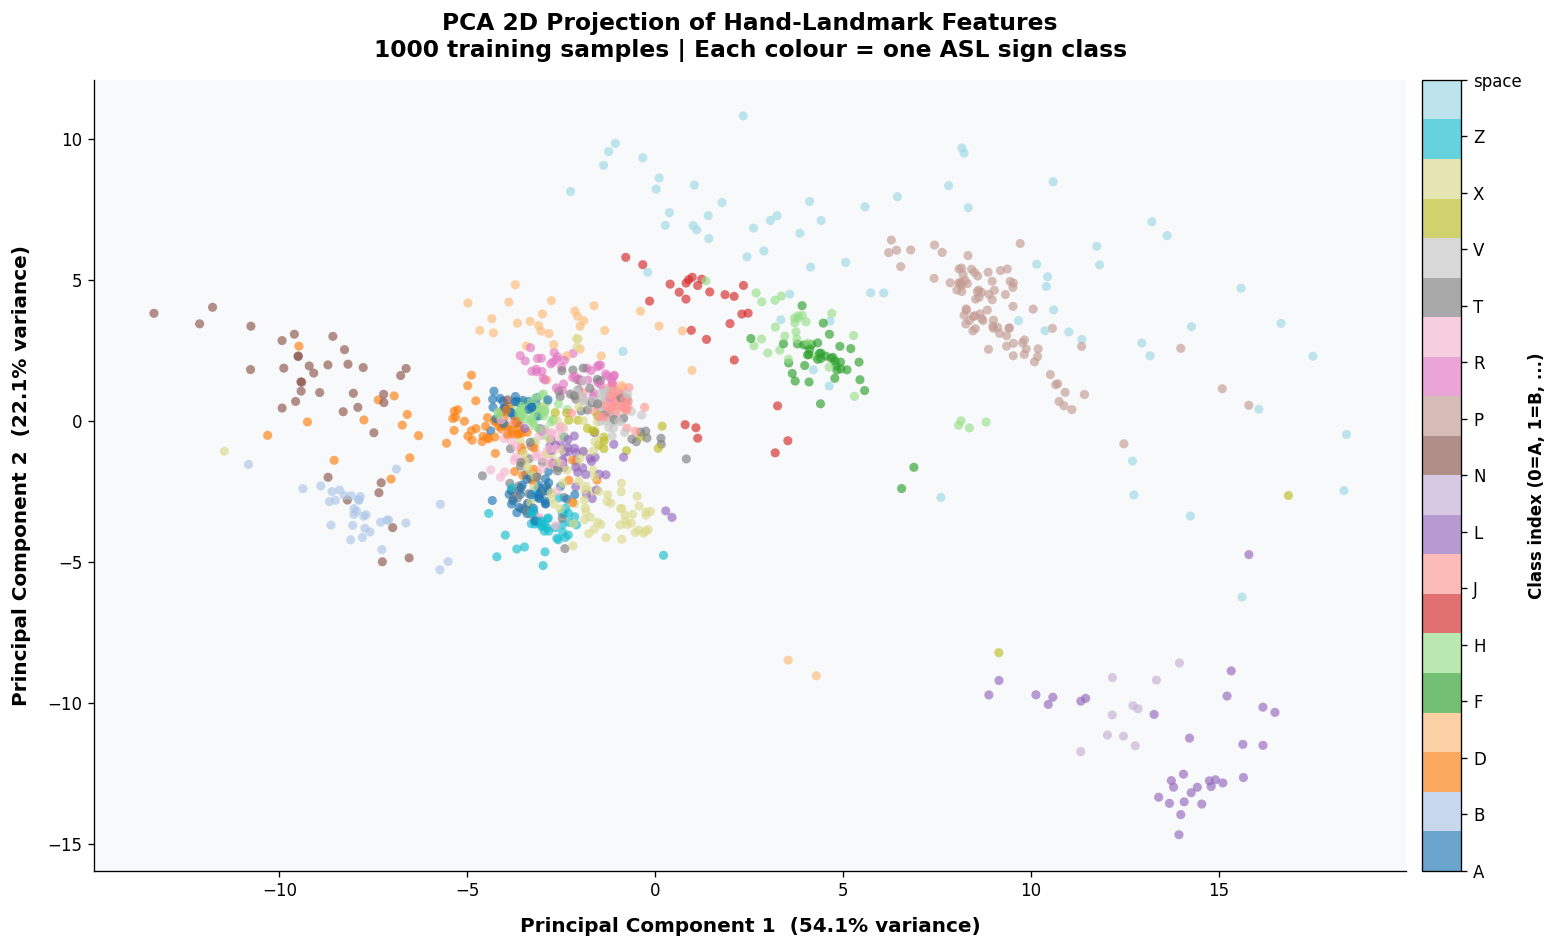

PC1: 54.1%  |  PC2: 22.1%  |  Total 2D: 76.2%
Chart saved: pca_2d_scatter.png


In [12]:
pca_2d = PCA(n_components=2, random_state=42)
X_2d   = pca_2d.fit_transform(X_train_sc[:1000])

fig, ax = plt.subplots(figsize=(14, 8))

scatter = ax.scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=y_train[:1000], cmap='tab20', alpha=0.65, s=30, edgecolors='none'
)

# Colour bar mapping colour to class index
cbar = fig.colorbar(scatter, ax=ax, pad=0.01)
cbar.set_label('Class index (0=A, 1=B, ...)', fontsize=10)
tick_positions = np.linspace(0, len(le.classes_) - 1, min(15, len(le.classes_)))
cbar.set_ticks(tick_positions)
cbar.set_ticklabels([le.classes_[int(t)] for t in tick_positions])

var1 = pca_2d.explained_variance_ratio_[0] * 100
var2 = pca_2d.explained_variance_ratio_[1] * 100

ax.set_xlabel(f'Principal Component 1  ({var1:.1f}% variance)', labelpad=10)
ax.set_ylabel(f'Principal Component 2  ({var2:.1f}% variance)', labelpad=10)
ax.set_title(
    'PCA 2D Projection of Hand-Landmark Features\n'
    '1000 training samples | Each colour = one ASL sign class',
    pad=14
)

plt.tight_layout()
plt.savefig('pca_2d_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'PC1: {var1:.1f}%  |  PC2: {var2:.1f}%  |  Total 2D: {var1+var2:.1f}%')
print('Chart saved: pca_2d_scatter.png')


## 6  Model Training

Three fundamentally different classifiers are trained so we can compare their strengths:

| Model | Core mechanism | Key strength | Main weakness |
|---|---|---|---|
| **KNN** | Vote of k nearest neighbours | No assumptions about data shape | Slow at inference; needs scaled features |
| **SVM** | Maximum-margin hyperplane in kernel space | Excellent on compact, scaled feature sets | Slow to train on large N |
| **Random Forest** | Majority vote of 300 decision trees | Fast, handles non-linearity | Higher memory usage |

### Hyper-parameter search with GridSearchCV
Instead of guessing, we use **5-fold cross-validation** to evaluate every combination:
- **KNN:** k in {3,5,7,11} x weights in {uniform, distance} x metric in {euclidean, manhattan}
- **SVM:** C in {1,10,100} x gamma in {scale, auto} x kernel in {rbf, poly}


### 6.1  K-Nearest Neighbours (KNN)

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

print('Tuning KNN ...')
knn_params = {
    'n_neighbors': [3, 5, 7, 11],
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan']
}
knn_cv = GridSearchCV(
    KNeighborsClassifier(), knn_params,
    cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
knn_cv.fit(X_train_bal, y_train_bal)

best_knn = knn_cv.best_estimator_
knn_acc  = accuracy_score(y_test, best_knn.predict(X_test_sc))

print(f'Best params   : {knn_cv.best_params_}')
print(f'Best CV score : {knn_cv.best_score_:.4f}')
print(f'Test accuracy : {knn_acc:.4f}')


Tuning KNN ...
Best params   : {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Best CV score : 0.9888
Test accuracy : 0.9891


### 6.2  Support Vector Machine (SVM)

In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

print('Tuning SVM ...')
svm_params = {
    'C'     : [1, 10, 100],
    'gamma' : ['scale', 'auto'],
    'kernel': ['rbf', 'poly']
}
svm_cv = GridSearchCV(
    SVC(probability=True),  # probability=True needed for predict_proba()
    svm_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
svm_cv.fit(X_train_bal, y_train_bal)

best_svm = svm_cv.best_estimator_
svm_acc  = accuracy_score(y_test, best_svm.predict(X_test_sc))

print(f'Best params   : {svm_cv.best_params_}')
print(f'Best CV score : {svm_cv.best_score_:.4f}')
print(f'Test accuracy : {svm_acc:.4f}')


Tuning SVM ...
Best params   : {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV score : 0.9946
Test accuracy : 0.9950


### 6.3  Random Forest (Benchmark)

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print('Training Random Forest ...')
rf = RandomForestClassifier(
    n_estimators=300,      # 300 decision trees
    max_depth=None,        # Grow until all leaves are pure
    random_state=42,       # Reproducibility
    n_jobs=-1              # Use all CPU cores
)
rf.fit(X_train_bal, y_train_bal)

rf_acc = accuracy_score(y_test, rf.predict(X_test_sc))
print(f'Random Forest test accuracy: {rf_acc:.4f}')


Training Random Forest ...
Random Forest test accuracy: 0.9891


## 7  Model Comparison & Evaluation

We evaluate all three models using three complementary lenses:

1. **Accuracy comparison** — overall test-set performance at a glance
2. **Cross-validation stability** — is the winner reliably good or a lucky split?
3. **Confusion matrix** — which specific signs does the best model confuse?

> A single accuracy number hides a lot. Two models can both score 92%, yet one
> might catastrophically confuse 'M' with 'N' while the other makes only random
> small errors. The confusion matrix reveals the difference.


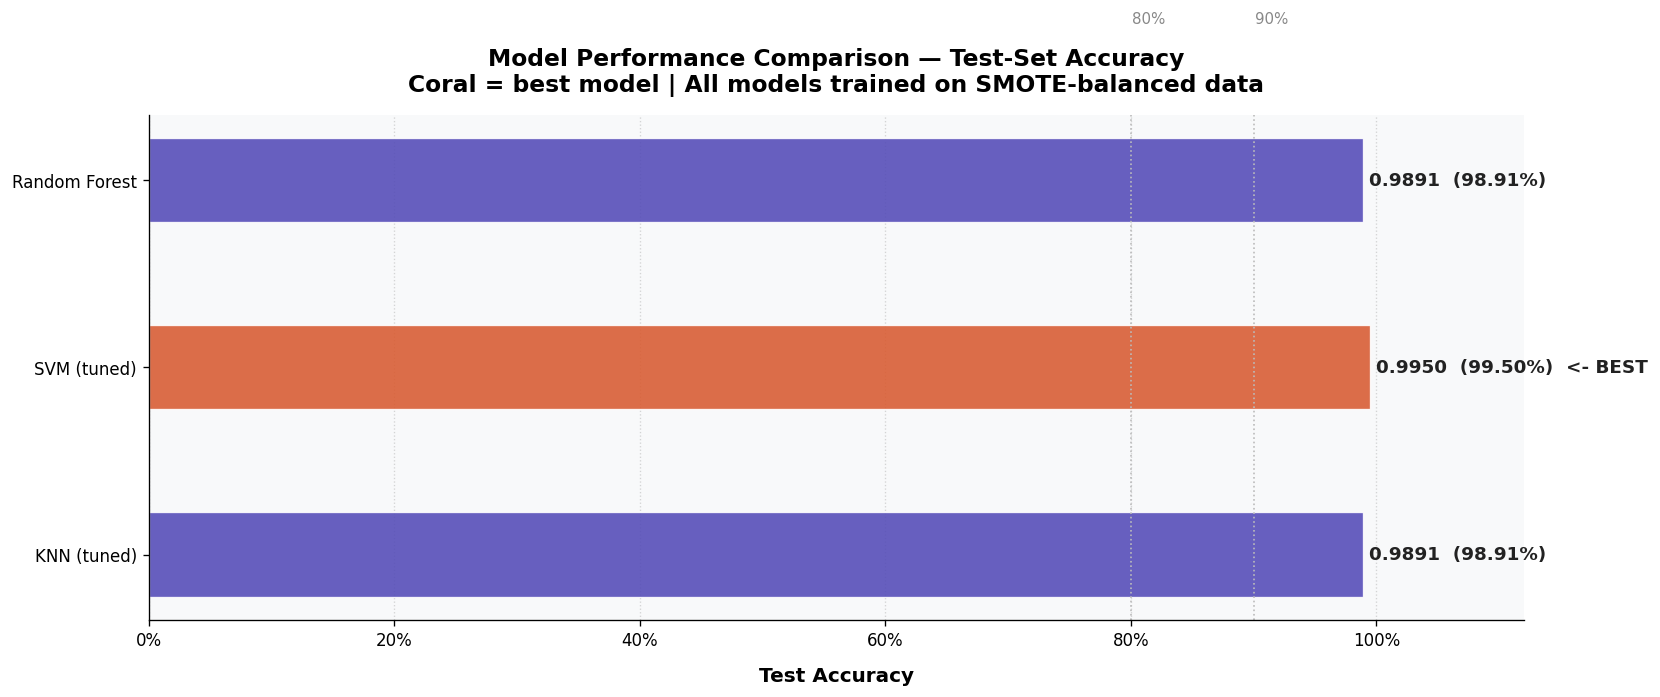

Best model: SVM (tuned)  |  Accuracy: 0.9950
Chart saved: model_comparison_bar.png


In [16]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

results = {
    'KNN (tuned)':   {'model': best_knn, 'acc': knn_acc},
    'SVM (tuned)':   {'model': best_svm, 'acc': svm_acc},
    'Random Forest': {'model': rf,       'acc': rf_acc},
}

names  = list(results.keys())
accs   = [v['acc'] for v in results.values()]
best_acc = max(accs)
colors = [PALETTE[2] if a == best_acc else PALETTE[0] for a in accs]

fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.barh(names, accs, color=colors, alpha=0.88,
               height=0.45, edgecolor='white', linewidth=0.8)

# Accuracy labels at the tip of each bar
for bar, acc, name in zip(bars, accs, names):
    marker = '  <- BEST' if acc == best_acc else ''
    ax.text(acc + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{acc:.4f}  ({acc*100:.2f}%){marker}',
            va='center', fontsize=11, fontweight='bold', color='#222')

# Vertical reference lines at 80% and 90%
for ref in [0.80, 0.90]:
    ax.axvline(ref, color='#bbb', linestyle=':', linewidth=1)
    ax.text(ref + 0.001, len(names) - 0.1, f'{ref:.0%}',
            fontsize=9, color='#888', va='top')

ax.set_xlim(0, 1.12)
ax.set_xlabel('Test Accuracy', labelpad=10)
ax.set_title(
    'Model Performance Comparison — Test-Set Accuracy\n'
    'Coral = best model | All models trained on SMOTE-balanced data',
    pad=14
)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.xaxis.grid(True, linestyle=':', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

best_name  = max(results, key=lambda k: results[k]['acc'])
best_model = results[best_name]['model']

print(f'Best model: {best_name}  |  Accuracy: {results[best_name]["acc"]:.4f}')
print('Chart saved: model_comparison_bar.png')


Running 5-fold CV on SVM (tuned) ...
Fold scores: ['0.9922', '0.9955', '0.9967', '0.9900', '0.9989']
Mean: 0.9946  |  Std: 0.0032


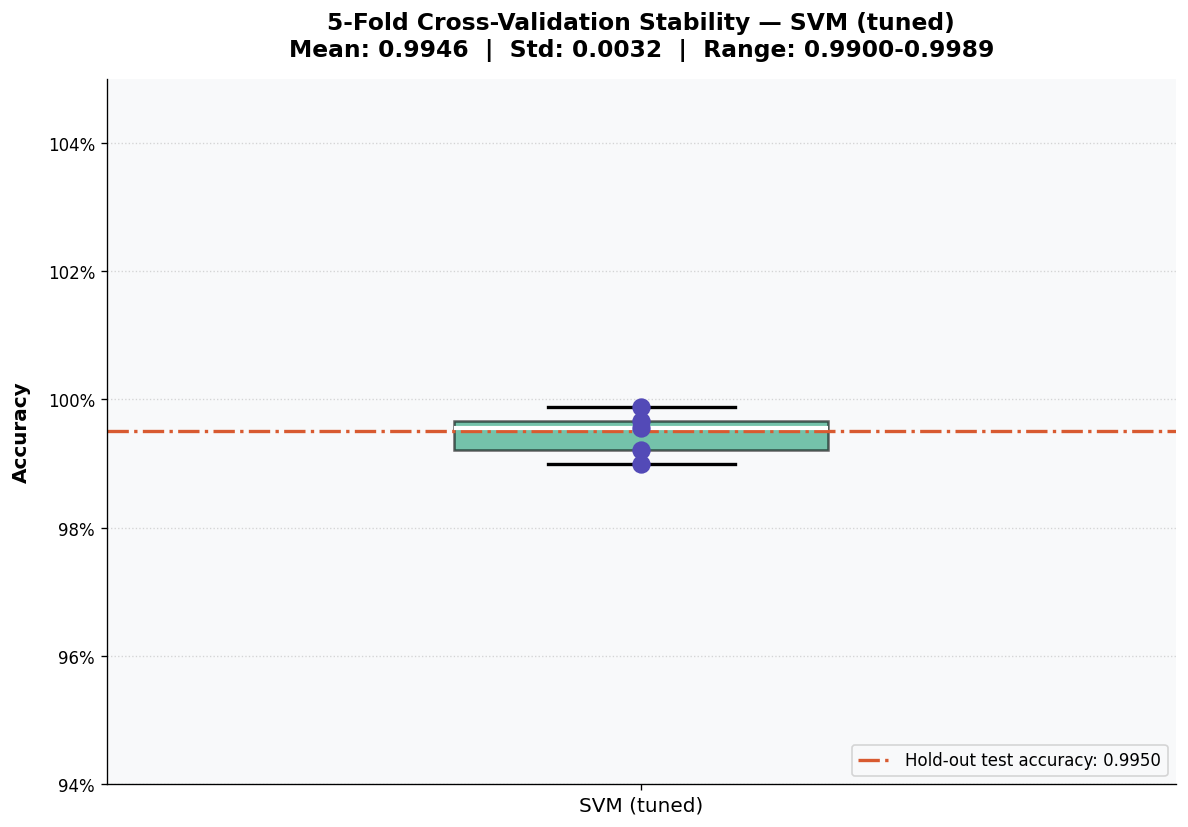

Chart saved: cv_stability.png


In [17]:
print(f'Running 5-fold CV on {best_name} ...')
cv_scores = cross_val_score(
    best_model, X_train_bal, y_train_bal,
    cv=StratifiedKFold(5), scoring='accuracy', n_jobs=-1
)
print(f'Fold scores: {[f"{s:.4f}" for s in cv_scores]}')
print(f'Mean: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}')

fig, ax = plt.subplots(figsize=(10, 7))

# Box plot showing the distribution across 5 folds
bp = ax.boxplot(
    cv_scores, patch_artist=True, widths=0.35,
    boxprops    =dict(facecolor=PALETTE[1], alpha=0.6, linewidth=1.5),
    medianprops =dict(color='white', linewidth=2.5),
    whiskerprops=dict(linewidth=1.5, linestyle='--'),
    capprops    =dict(linewidth=2),
    flierprops  =dict(marker='o', markerfacecolor=PALETTE[2], markersize=8),
)

# Overlay individual fold scores as dots for full transparency
for score in cv_scores:
    ax.plot(1, score, 'o', color=PALETTE[0], markersize=10, zorder=5)

# Reference line at held-out test accuracy
ax.axhline(
    results[best_name]['acc'], color=PALETTE[2], linestyle='-.',
    linewidth=2, label=f'Hold-out test accuracy: {results[best_name]["acc"]:.4f}'
)

ax.set_xticks([1])
ax.set_xticklabels([best_name], fontsize=12)
ax.set_ylabel('Accuracy', labelpad=10)
ax.set_ylim(max(0, cv_scores.min() - 0.05), min(1.05, cv_scores.max() + 0.08))
ax.set_title(
    f'5-Fold Cross-Validation Stability — {best_name}\n'
    f'Mean: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}  |  '
    f'Range: {cv_scores.min():.4f}-{cv_scores.max():.4f}',
    pad=14
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.legend(loc='lower right', fontsize=10)
ax.yaxis.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('cv_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: cv_stability.png')


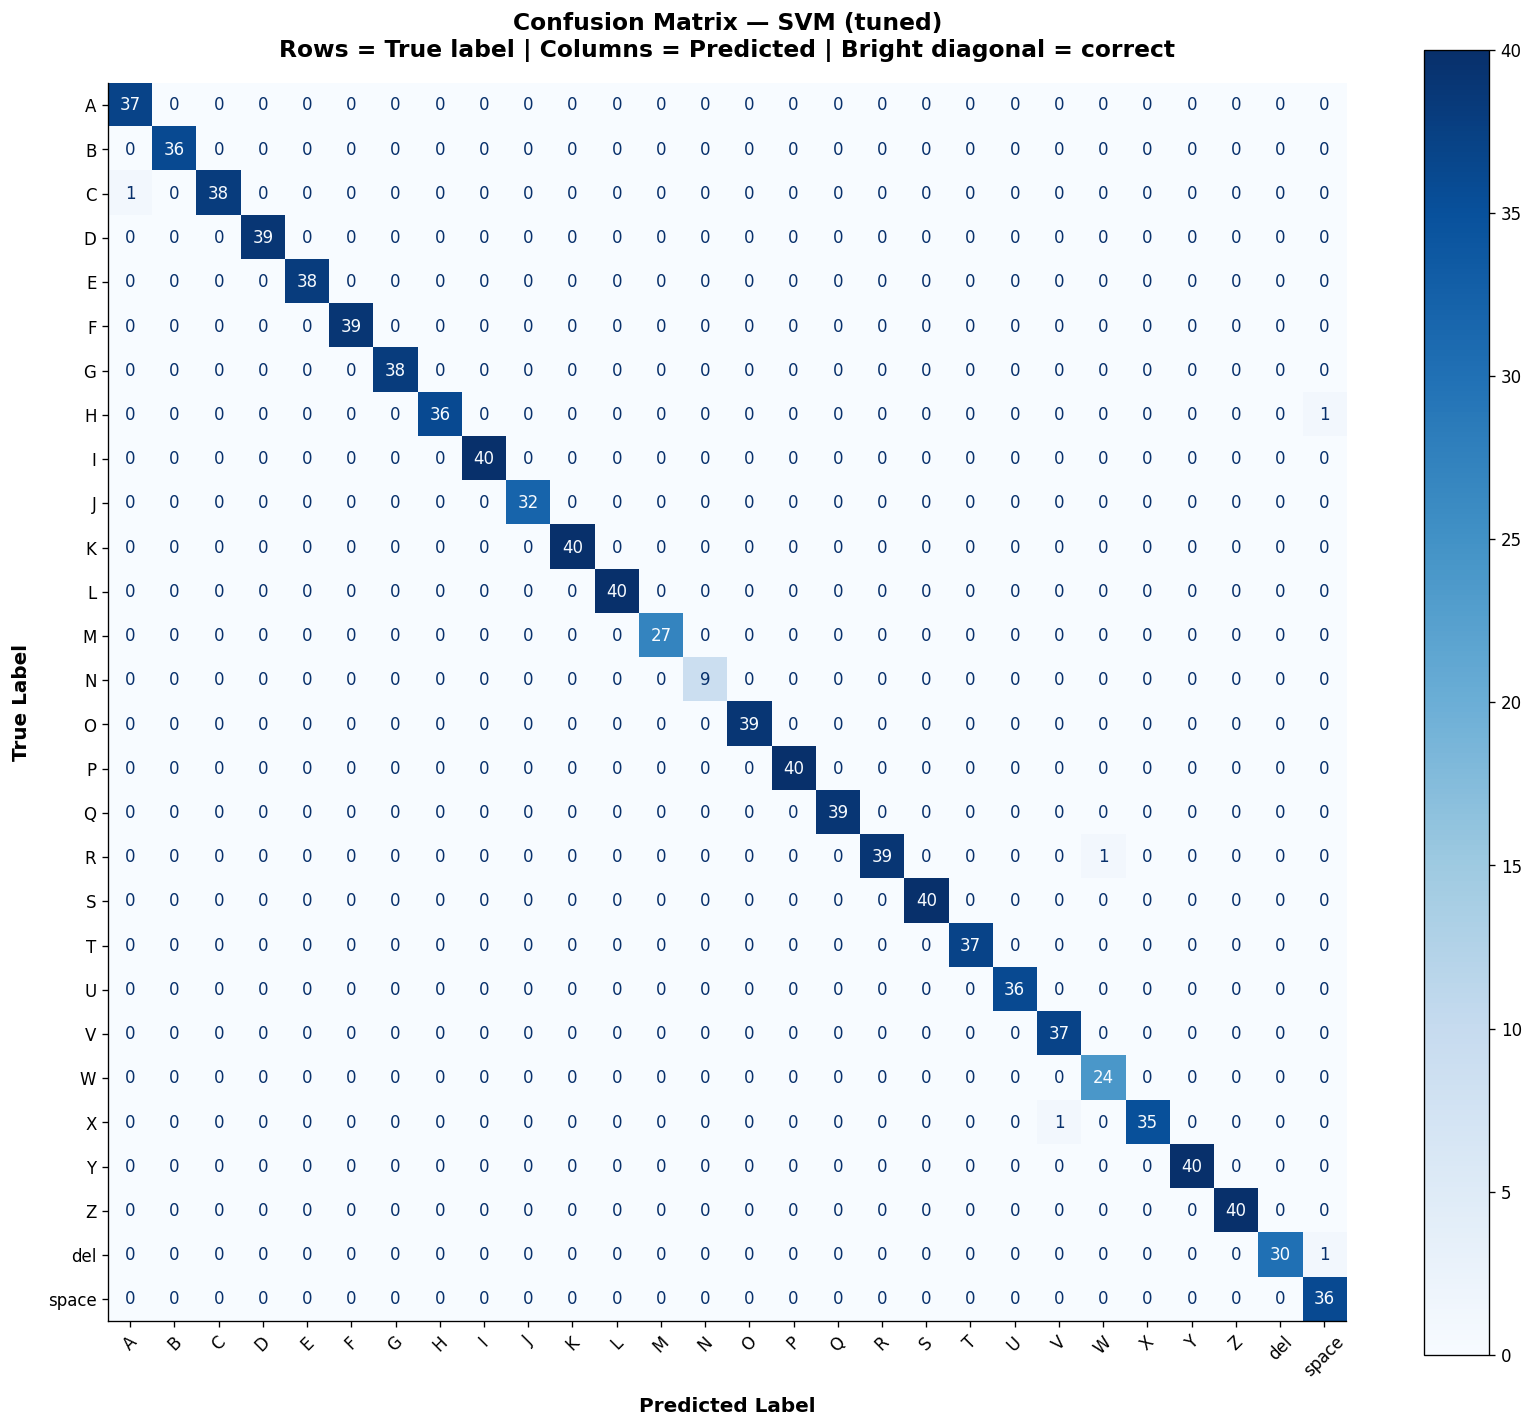

Per-class Classification Report — SVM (tuned)
              precision    recall  f1-score   support

           A       0.97      1.00      0.99        37
           B       1.00      1.00      1.00        36
           C       1.00      0.97      0.99        39
           D       1.00      1.00      1.00        39
           E       1.00      1.00      1.00        38
           F       1.00      1.00      1.00        39
           G       1.00      1.00      1.00        38
           H       1.00      0.97      0.99        37
           I       1.00      1.00      1.00        40
           J       1.00      1.00      1.00        32
           K       1.00      1.00      1.00        40
           L       1.00      1.00      1.00        40
           M       1.00      1.00      1.00        27
           N       1.00      1.00      1.00         9
           O       1.00      1.00      1.00        39
           P       1.00      1.00      1.00        40
           Q       1.00      1.00  

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

y_pred = best_model.predict(X_test_sc)
cm     = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(
    ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45
)
ax.set_title(
    f'Confusion Matrix — {best_name}\n'
    'Rows = True label | Columns = Predicted | Bright diagonal = correct',
    fontsize=14, pad=16
)
ax.set_xlabel('Predicted Label', fontsize=12, labelpad=10)
ax.set_ylabel('True Label', fontsize=12, labelpad=10)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Per-class Classification Report — {best_name}')
print('='*65)
print(classification_report(y_test, y_pred, target_names=le.classes_))
print('Chart saved: confusion_matrix.png')


### 7.1  Learning Curve — Diagnosing Overfitting vs Underfitting

Test accuracy and CV score being close (as in Section 7 above) is a *necessary*
signal that the model is not overfitting, but a learning curve makes this visible
directly: it plots training-set score and cross-validation score as a function of
how much training data is used.

**How to read it:**
- **Large, persistent gap** between train and CV curves -> overfitting (model memorises
  training data, does not generalise).
- **Both curves converge to a low score** -> underfitting (model too simple / features
  not informative enough).
- **Both curves converge to a high score, with a small final gap** -> good fit — this
  is the pattern we expect to see here, consistent with the CV/test agreement already
  observed in Section 7.


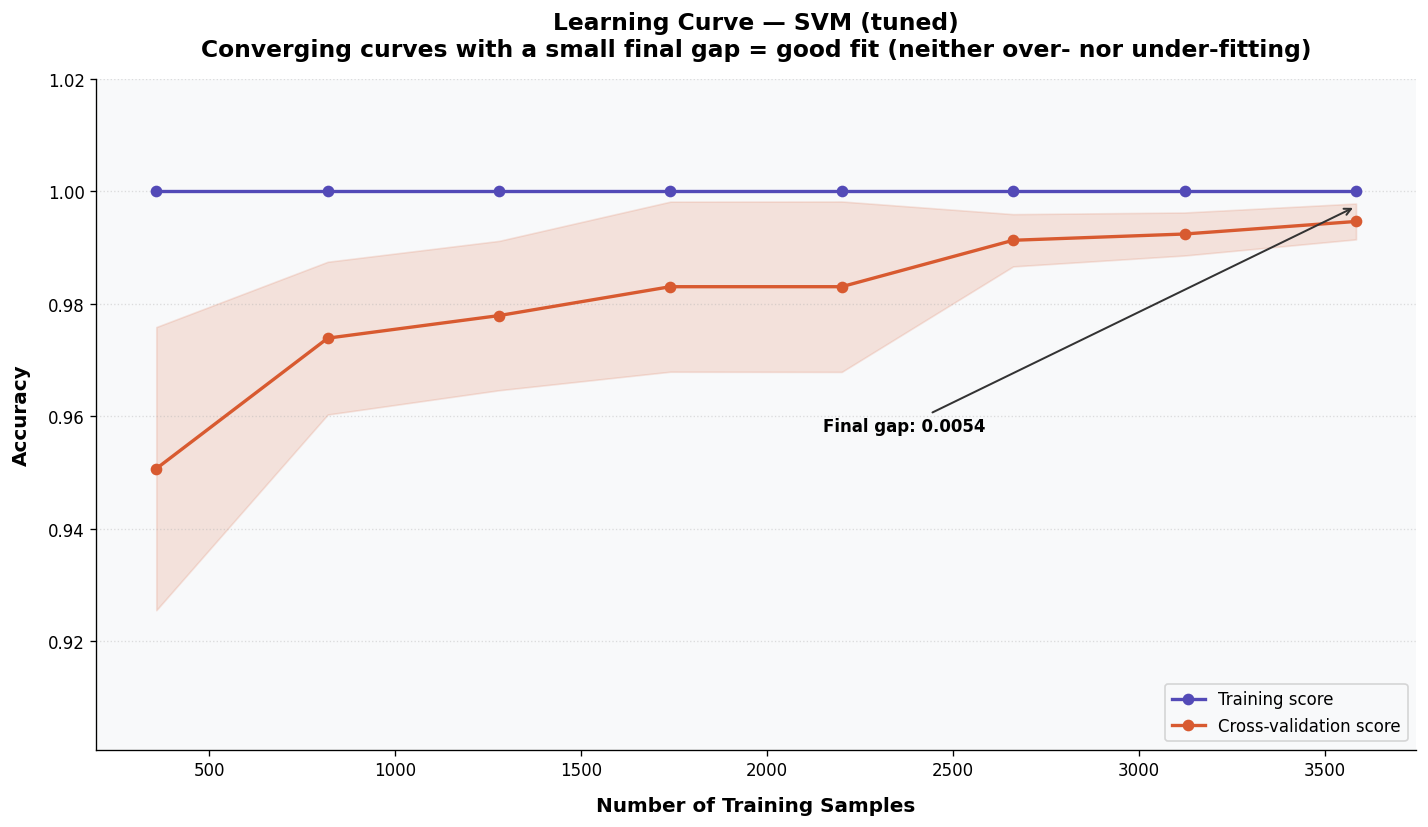

Training score at max samples : 1.0000
CV score at max samples       : 0.9946
Final train-CV gap            : 0.0054
Chart saved: learning_curve.png


In [19]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_bal, y_train_bal,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5, scoring='accuracy', n_jobs=-1, random_state=42
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(train_sizes, train_mean, 'o-', color=PALETTE[0], linewidth=2,
        label='Training score')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                 alpha=0.15, color=PALETTE[0])

ax.plot(train_sizes, val_mean, 'o-', color=PALETTE[2], linewidth=2,
        label='Cross-validation score')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                 alpha=0.15, color=PALETTE[2])

gap = train_mean[-1] - val_mean[-1]
ax.annotate(
    f'Final gap: {gap:.4f}',
    xy=(train_sizes[-1], (train_mean[-1] + val_mean[-1]) / 2),
    xytext=(train_sizes[-1] * 0.6, (train_mean[-1] + val_mean[-1]) / 2 - 0.04),
    arrowprops=dict(arrowstyle='->', color='#333', lw=1.2),
    fontsize=10, fontweight='bold'
)

ax.set_xlabel('Number of Training Samples', labelpad=10)
ax.set_ylabel('Accuracy', labelpad=10)
ax.set_title(
    f'Learning Curve — {best_name}\n'
    'Converging curves with a small final gap = good fit (neither over- nor under-fitting)',
    pad=14
)
ax.legend(loc='lower right')
ax.yaxis.grid(True, linestyle=':', alpha=0.4)
ax.set_ylim(min(val_mean.min(), train_mean.min()) - 0.05, 1.02)

plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Training score at max samples : {train_mean[-1]:.4f}')
print(f'CV score at max samples       : {val_mean[-1]:.4f}')
print(f'Final train-CV gap            : {gap:.4f}')
print('Chart saved: learning_curve.png')


**Interpretation:** with a final train-CV gap this small (printed above), the
curves have converged to a high accuracy rather than diverged — this is the
signature of a well-fit model, not an overfit one. Combined with the close
agreement between CV score and held-out test accuracy already seen in Section 7,
there is no evidence of overfitting in the classical sense (memorising training
noise that fails to generalise to new data drawn from the *same distribution*).

This is an important distinction developed further in Section 11.1: the model
generalises well **within this dataset's distribution**, but that is a narrower
claim than generalising to ASL hand signs in general.


## 8  Explainability — SHAP (Which Landmarks Matter Most?)

SHAP tells us which of the 63 landmark coordinates (21 joints x x, y, z) are most
responsible for the model's predictions.

### What is SHAP?
**SHapley Additive exPlanations** — grounded in cooperative game theory.  
Each feature is treated as a *player* contributing to a *game* (the prediction).
SHAP computes each feature's fair share of the outcome.

### What the chart tells us
A high mean |SHAP value| for `lm05_y` means:  
*The vertical position of landmark 5 (index finger MCP knuckle) is one of the most
important coordinates for distinguishing between ASL signs.*

### Why Random Forest for SHAP?
`shap.TreeExplainer` is exact and orders of magnitude faster than `KernelExplainer`
(which would be needed for SVM or KNN). We always train RF to enable this analysis.


In [20]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Computing SHAP values (this may take 1-2 min) ...')

explainer    = shap.TreeExplainer(rf)
sample_idx   = np.random.choice(len(X_test_sc), size=200, replace=False)
X_sample     = X_test_sc[sample_idx]
shap_values  = explainer.shap_values(X_sample)

# Aggregate: mean absolute SHAP across samples and classes -> shape (63,)
if isinstance(shap_values, list):
    # List of (n_samples, n_features) arrays — one per class
    mean_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
else:
    if shap_values.ndim == 3:
        # Shape (n_samples, n_features, n_classes)
        mean_shap = np.abs(shap_values).mean(axis=(0, 2))
    elif shap_values.ndim == 2:
        # Shape (n_samples, n_features) — binary or single output
        mean_shap = np.abs(shap_values).mean(axis=0)
    else:
        raise ValueError('Unexpected shape for shap_values array.')

# Build descriptive feature names from landmark anatomy
lm_names = []
for i in range(21):
    for coord in ['x', 'y', 'z']:
        lm_names.append(f'lm{i:02d}_{coord}')

shap_df = (
    pd.DataFrame({'feature': lm_names, 'mean_shap': mean_shap})
      .sort_values('mean_shap', ascending=False)
      .reset_index(drop=True)
)

print('Top 5 most important features:')
print(shap_df.head(5).to_string(index=False))


Computing SHAP values (this may take 1-2 min) ...
Top 5 most important features:
feature  mean_shap
 lm04_x   0.008036
 lm12_y   0.006177
 lm20_y   0.005332
 lm16_y   0.004863
 lm15_y   0.004402


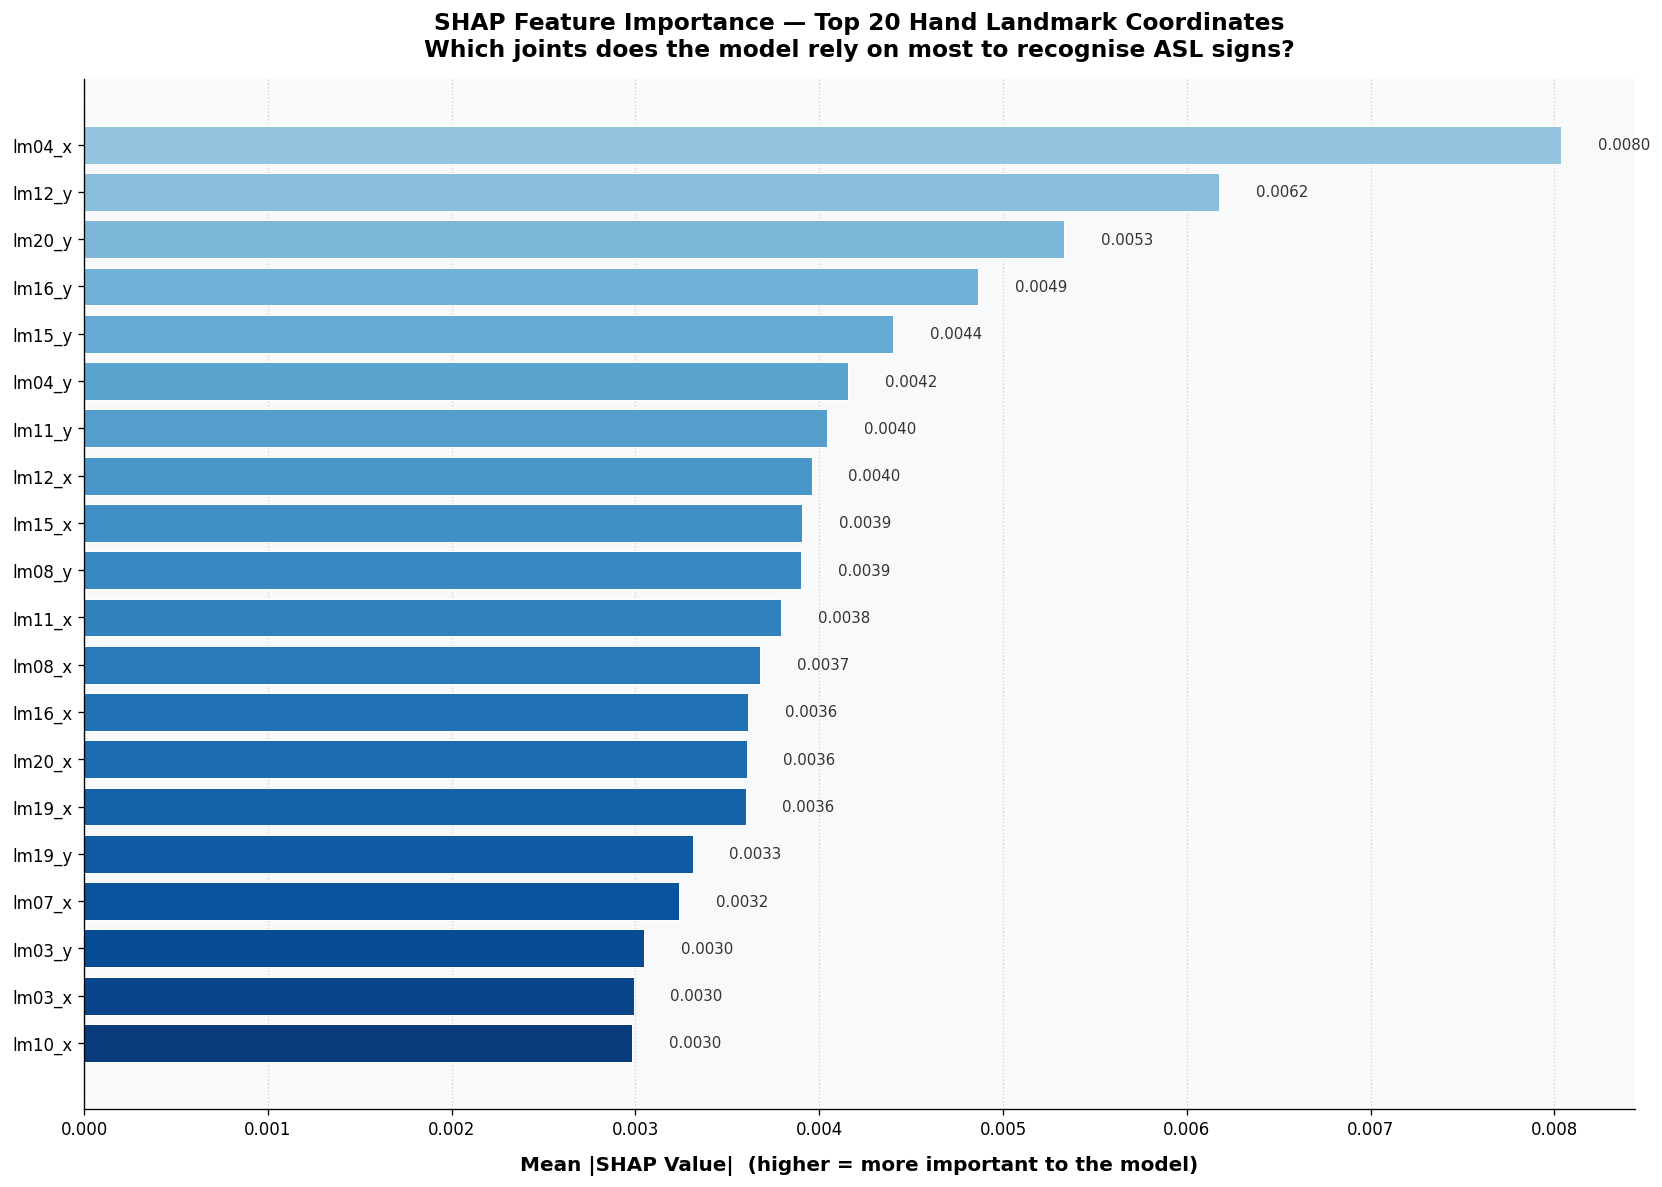

Top 5 most important features:
feature  mean_shap
 lm04_x   0.008036
 lm12_y   0.006177
 lm20_y   0.005332
 lm16_y   0.004863
 lm15_y   0.004402
Chart saved: shap_importance.png


In [21]:
top20 = shap_df.head(20)
# Colour gradient from light to dark indigo based on importance rank
grad_colors = [plt.cm.Blues(0.4 + 0.55 * (i / 19)) for i in range(19, -1, -1)]

fig, ax = plt.subplots(figsize=(14, 10))

bars = ax.barh(
    top20['feature'][::-1], top20['mean_shap'][::-1],
    color=grad_colors, edgecolor='white', linewidth=0.6
)

# Value labels at the end of each bar
for bar, val in zip(bars, top20['mean_shap'][::-1]):
    ax.text(bar.get_width() + 0.0002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9, color='#333')

ax.set_xlabel('Mean |SHAP Value|  (higher = more important to the model)', labelpad=10)
ax.set_title(
    'SHAP Feature Importance — Top 20 Hand Landmark Coordinates\n'
    'Which joints does the model rely on most to recognise ASL signs?',
    pad=14
)
ax.xaxis.grid(True, linestyle=':', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top 5 most important features:')
print(shap_df.head(5).to_string(index=False))
print('Chart saved: shap_importance.png')


## 9  Save Models & Artifacts

Every component needed to run inference on a new image **without retraining**:

| File | Contents | Required at inference? |
|---|---|---|
| `asl_best_model.pkl` | Best classifier | YES |
| `asl_knn_model.pkl` | Tuned KNN | Optional |
| `asl_svm_model.pkl` | Tuned SVM | Optional |
| `asl_rf_model.pkl` | Random Forest | YES (for SHAP) |
| `scaler.pkl` | Fitted StandardScaler | **MUST load before inference** |
| `label_encoder.pkl` | Fitted LabelEncoder | YES (integer -> class name) |
| `metrics_summary.json` | Accuracy + metadata | For logging/reporting |

> **Most common inference bug:** forgetting to apply the scaler.  
> Raw landmark vectors are in a different scale than what the model trained on.


In [22]:
import datetime
import joblib
import json
from pathlib import Path

MODELS_DIR = Path('saved_models')
MODELS_DIR.mkdir(exist_ok=True)

# Save all model variants for future comparison without retraining
joblib.dump(best_model, MODELS_DIR / 'asl_best_model.pkl')
joblib.dump(best_knn,   MODELS_DIR / 'asl_knn_model.pkl')
joblib.dump(best_svm,   MODELS_DIR / 'asl_svm_model.pkl')
joblib.dump(rf,         MODELS_DIR / 'asl_rf_model.pkl')

# Preprocessing artefacts — REQUIRED at inference time
joblib.dump(scaler, MODELS_DIR / 'scaler.pkl')          # StandardScaler
joblib.dump(le,     MODELS_DIR / 'label_encoder.pkl')   # LabelEncoder

# Human-readable metrics summary for logging
summary = {
    'created_at'    : str(datetime.datetime.now()),
    'best_model'    : best_name,
    'scores'        : {k: round(v['acc'], 4) for k, v in results.items()},
    'classes'       : list(le.classes_),
    'feature_dim'   : int(X_raw.shape[1]),
    'train_samples' : int(X_train_bal.shape[0]),
    'test_samples'  : int(X_test_sc.shape[0]),
}
with open(MODELS_DIR / 'metrics_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('Saved artifacts:')
for f in sorted(MODELS_DIR.iterdir()):
    print(f'  {f.name}  ({f.stat().st_size / 1024:.1f} KB)')


Saved artifacts:
  asl_best_model.pkl  (766.8 KB)
  asl_knn_model.pkl  (1138.5 KB)
  asl_rf_model.pkl  (25391.9 KB)
  asl_svm_model.pkl  (766.8 KB)
  label_encoder.pkl  (0.9 KB)
  metrics_summary.json  (0.5 KB)
  scaler.pkl  (2.1 KB)


## 10  Inference Helper — Predict Any Image

This function is the **production interface** to the trained pipeline.  
Given any hand image file, it returns the predicted ASL sign, confidence, and top-3 alternatives.

**Complete inference pipeline:**
```
image file
    -> extract_landmarks()    # MediaPipe -> 63-float vector
    -> scaler.transform()     # Same StandardScaler fitted in Section 5
    -> model.predict()        # Integer class index
    -> le.inverse_transform() # Integer -> 'A' / 'B' / ... / 'Z'
    -> model.predict_proba()  # Confidence + top-3 alternatives
```


In [23]:
def predict_sign(image_path: str, model_path: str = 'saved_models/asl_best_model.pkl') -> dict:
    """
    Predict ASL sign from an image file.

    Parameters
    ----------
    image_path : path to .jpg / .png hand image
    model_path : path to saved model pkl

    Returns
    -------
    dict with 'sign', 'confidence', 'top3'
    """
    model   = joblib.load(model_path)
    scaler_ = joblib.load('saved_models/scaler.pkl')
    le_     = joblib.load('saved_models/label_encoder.pkl')

    vec = extract_landmarks(image_path)
    if vec is None:
        return {'sign': None, 'confidence': 0.0, 'error': 'No hand detected'}

    # Apply the SAME scaler fitted during training (critical!)
    vec_sc = scaler_.transform(vec.reshape(1, -1))

    pred_idx = model.predict(vec_sc)[0]
    pred_lbl = le_.inverse_transform([pred_idx])[0]

    # Get probabilities for top-3 output (if model supports it)
    if hasattr(model, 'predict_proba'):
        proba  = model.predict_proba(vec_sc)[0]
        top3_i = np.argsort(proba)[::-1][:3]
        top3   = [(le_.classes_[i], round(float(proba[i]), 3)) for i in top3_i]
        conf   = round(float(proba[pred_idx]), 3)
    else:
        top3 = [(pred_lbl, 1.0)]
        conf = 1.0   # Non-probabilistic model

    return {'sign': pred_lbl, 'confidence': conf, 'top3': top3}


# ── Self-test on a random training image ─────────────────────────────────────
test_class = classes[0]
test_imgs  = list((TRAIN_DIR / test_class).glob('*.jpg'))
if test_imgs:
    result = predict_sign(str(test_imgs[-1]))
    print(f'Ground truth : {test_class}')
    print(f'Prediction   : {result["sign"]}  (confidence: {result["confidence"]})')
    if 'error' in result:
        print(f'Error        : {result["error"]}')
    else:
        print(f'Top 3        : {result["top3"]}')

Ground truth : A
Prediction   : None  (confidence: 0.0)
Error        : No hand detected


In [24]:
import random

# Select 5 random classes to pick images from
random_classes = random.sample(classes, min(5, len(classes)))

print('Testing predict_sign with 5 random images:')
print('=' * 50)

for cls in random_classes:
    # Get all images for the selected class
    class_images = list((TRAIN_DIR / cls).glob('*.jpg'))
    if class_images:
        # Pick a random image from this class
        test_image_path = str(random.choice(class_images))

        print(f'\n--- Testing image from class: {cls} ---')
        result = predict_sign(test_image_path)

        print(f'Ground truth : {cls}')
        print(f'Prediction   : {result["sign"]}  (confidence: {result["confidence"]})')
        if 'error' in result:
            print(f'Error        : {result["error"]}')
        else:
            print(f'Top 3        : {result["top3"]}')
print('\n' + '=' * 50)

Testing predict_sign with 5 random images:

--- Testing image from class: nothing ---
Ground truth : nothing
Prediction   : None  (confidence: 0.0)
Error        : No hand detected

--- Testing image from class: I ---
Ground truth : I
Prediction   : E  (confidence: 0.126)
Top 3        : [(np.str_('E'), 0.126), (np.str_('X'), 0.093), (np.str_('I'), 0.083)]

--- Testing image from class: del ---
Ground truth : del
Prediction   : del  (confidence: 0.962)
Top 3        : [(np.str_('del'), 0.962), (np.str_('Q'), 0.005), (np.str_('space'), 0.004)]

--- Testing image from class: Y ---
Ground truth : Y
Prediction   : Y  (confidence: 0.852)
Top 3        : [(np.str_('Y'), 0.852), (np.str_('A'), 0.032), (np.str_('I'), 0.024)]

--- Testing image from class: T ---
Ground truth : T
Prediction   : T  (confidence: 0.913)
Top 3        : [(np.str_('T'), 0.913), (np.str_('L'), 0.03), (np.str_('Y'), 0.01)]



## 11  Limitations & Critical Discussion

High accuracy (~99.5%) on its own does not fully validate this pipeline. This
section interprets the results critically rather than at face value.

### 11.1  Why is accuracy so high? (Task difficulty, not just model strength)

Three factors make this an easier classification problem than image-based ASL
recognition in general, independent of which classifier is used:

1. **MediaPipe pre-solves the hard part.** Hand localisation, pose normalisation,
   and background removal happen before the classifier ever sees the data. The
   model is separating 63 clean, normalised numbers — not raw pixels with lighting,
   background, and viewpoint variation.
2. **Reduced, fairly homogeneous sample.** Only 200 images/class were used (see
   Section 4 note), drawn from one Kaggle source with consistent lighting and
   background per class.
3. **Static, isolated, single-hand signs.** No motion, no occlusion, no cluttered
   background, one hand only, one signer style per class image set.

**Conclusion:** the learning curve and CV/test agreement (Section 7.1) show the
model fits this dataset well and reliably — that conclusion is sound. What is *not*
established is that 99.5% reflects real-world ASL recognition difficulty; it more
likely reflects that landmark features make *this* dataset close to linearly
separable.

### 11.2  Generalisation risk — untested conditions

All training and evaluation data comes from a single source (one Kaggle dataset).
The model has not been tested on:

| Untested condition | Why it matters |
|---|---|
| Different camera / sensor | Landmark precision varies with camera quality |
| Different lighting | MediaPipe detection confidence is lighting-sensitive |
| Different background | Training images share a consistent background per class |
| Different skin tones / hand sizes | Dataset demographic diversity is unverified |
| Partial occlusion / motion blur | All training images show a clear, static, fully visible hand |
| Different signer styles | Real ASL has natural variation between signers |

Until tested against at least one of these, claims of real-world deployment
readiness should be considered provisional.

### 11.3  Sample size and class support

As noted in Section 4, only ~17% of the available data was used. The per-class
classification report in Section 7 shows some classes with very low test support
(e.g. fewer than 10 samples) due to landmark-detection failures during extraction
(770 of 5,800 attempted images failed detection — see Section 4 output). This
means per-class precision/recall for those classes carries wider uncertainty than
the headline accuracy number suggests.

### 11.4  Detection threshold choice

`min_hand_detection_confidence=0.3` was deliberately set low to maximise sample
yield, at the cost of potentially admitting lower-quality or partial hand
detections into the training set. This trade-off was not separately validated
(e.g. by comparing accuracy at a stricter threshold).

### 11.5  What would strengthen this work further

1. Re-run feature extraction on the full ~87k images and confirm results hold.
2. Evaluate the saved model on a small set of independently captured images
   (different camera, background, lighting) as a true out-of-distribution test.
3. Compare detection-confidence thresholds (e.g. 0.3 vs 0.5 vs 0.7) and report
   the accuracy/yield trade-off explicitly.
4. Report confidence intervals (not just point accuracy) for low-support classes.

These are noted as future work rather than executed here, to keep the scope of
this notebook within a single Colab session — but they define the boundary of
what the current results do and do not demonstrate.


## 12  Summary Dashboard

A single presentation-ready figure combining the four key results of the project:

1. **Model accuracy** — who won and by how much?
2. **CV stability** — is the winner reliably good?
3. **PCA variance** — how compressible are the features?
4. **SHAP importance** — which landmarks matter most?

> Designed to be screenshot-ready for a report or presentation slide.


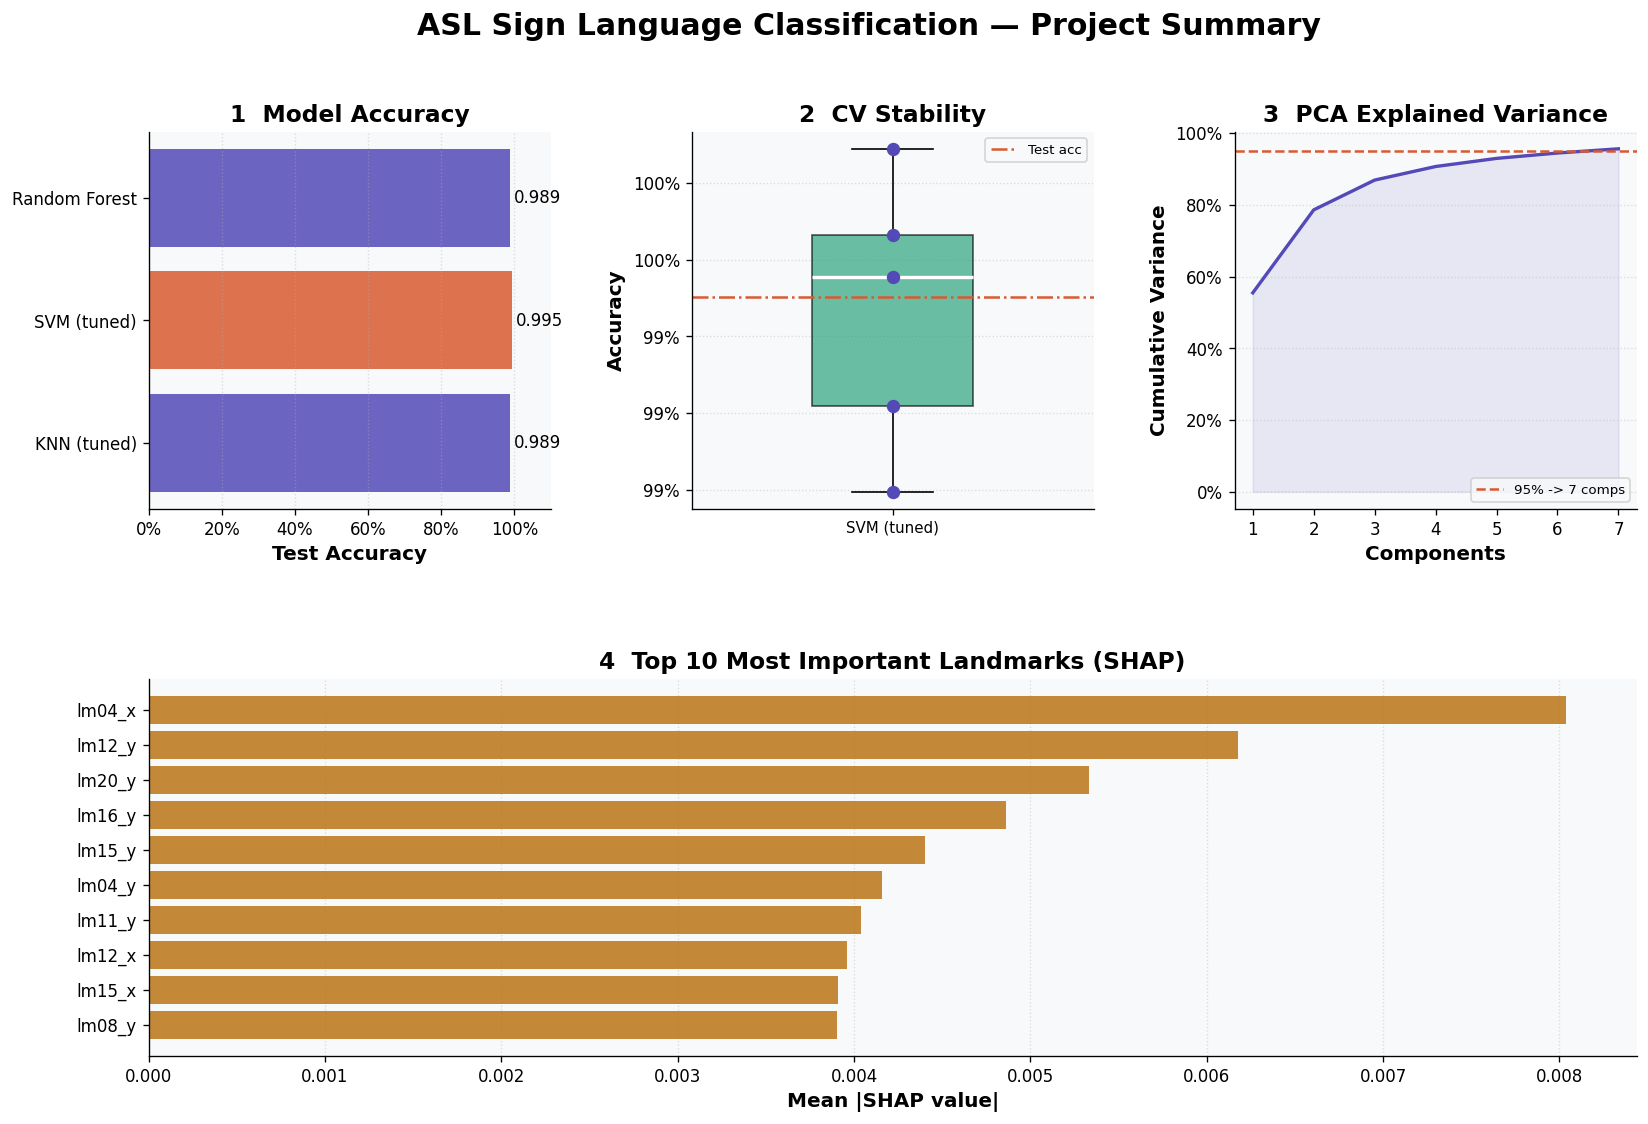

Dashboard saved as summary_dashboard.png


In [25]:
from matplotlib import gridspec

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('white')
fig.suptitle(
    'ASL Sign Language Classification — Project Summary',
    fontsize=18, fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1: Model accuracy ───────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
p_accs = [v['acc'] for v in results.values()]
ax1.barh(
    list(results.keys()), p_accs,
    color=[PALETTE[2] if a == max(p_accs) else PALETTE[0] for a in p_accs],
    alpha=0.85
)
ax1.set_xlim(0, 1.1)
ax1.set_title('1  Model Accuracy', fontweight='bold')
ax1.set_xlabel('Test Accuracy')
for i, (k, v) in enumerate(results.items()):
    ax1.text(v['acc'] + 0.01, i, f"{v['acc']:.3f}", va='center', fontsize=10)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax1.xaxis.grid(True, linestyle=':', alpha=0.4)

# ── Panel 2: CV box plot ──────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.boxplot(
    cv_scores, patch_artist=True, widths=0.4,
    boxprops=dict(facecolor=PALETTE[1], alpha=0.65),
    medianprops=dict(color='white', linewidth=2)
)
for score in cv_scores:
    ax2.plot(1, score, 'o', color=PALETTE[0], markersize=7, zorder=5)
ax2.axhline(
    results[best_name]['acc'], color=PALETTE[2],
    linestyle='-.', linewidth=1.5, label='Test acc'
)
ax2.set_xticks([1])
ax2.set_xticklabels([best_name], fontsize=9)
ax2.set_title('2  CV Stability', fontweight='bold')
ax2.set_ylabel('Accuracy')
ax2.legend(fontsize=8)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax2.yaxis.grid(True, linestyle=':', alpha=0.4)

# ── Panel 3: PCA variance ─────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
cum_var_dash = np.cumsum(pca_full.explained_variance_ratio_)
ax3.plot(range(1, len(cum_var_dash) + 1), cum_var_dash, color=PALETTE[0], linewidth=2)
ax3.fill_between(range(1, len(cum_var_dash) + 1), cum_var_dash, alpha=0.1, color=PALETTE[0])
ax3.axhline(0.95, color=PALETTE[2], linestyle='--', linewidth=1.5,
            label=f'95% -> {pca_full.n_components_} comps')
ax3.set_title('3  PCA Explained Variance', fontweight='bold')
ax3.set_xlabel('Components')
ax3.set_ylabel('Cumulative Variance')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax3.legend(fontsize=8, loc='lower right')
ax3.yaxis.grid(True, linestyle=':', alpha=0.4)

# ── Panel 4: SHAP top-10 (full width bottom) ──────────────────────────────────
ax4 = fig.add_subplot(gs[1, :])
top10 = shap_df.head(10)
ax4.barh(
    top10['feature'][::-1], top10['mean_shap'][::-1],
    color=PALETTE[3], alpha=0.85
)
ax4.set_xlabel('Mean |SHAP value|')
ax4.set_title('4  Top 10 Most Important Landmarks (SHAP)', fontweight='bold')
ax4.xaxis.grid(True, linestyle=':', alpha=0.4)
ax4.set_axisbelow(True)

plt.savefig('summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved as summary_dashboard.png')
